## Advandex: предсказание вероятности клика с помощью бинарной классификации

Задача заключается в построении модель бинарной классификации, которая предсказывает вероятность клика (CTR) на рекламное объявление. Необходимо провести калибровку этой модели, чтобы обеспечить соответствие между предсказанными вероятностями и фактической частотой кликов.

- Модель используют в рекламных аукционах в режиме реального времени для определения победителя. Рекламу победителя покажут пользователю.
- Точные вероятности критичны для расчёта ожидаемого дохода по формуле Ставка × Предсказанный CTR.
- Требуется интерпретируемость: нужно понимать, какие факторы влияют на клик.

# Структура проекта

## 1. Подготовка среды и загрузка данных

In [1]:
!pip install phik -q

In [2]:
!pip install category_encoders -q

In [3]:
import pandas as pd
import numpy as np
import phik

import sys

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from category_encoders import TargetEncoder
#from sklearn.preprocessing import TargetEncoder - выдает ошибку
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate, 
    GridSearchCV
)

from sklearn.feature_selection import RFE, VarianceThreshold, RFECV
from sklearn.feature_selection import SequentialFeatureSelector as SFS 

from sklearn.metrics import (
    average_precision_score,
    log_loss,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.base import clone

from scipy.special import expit

import joblib
import json

from pathlib import Path

In [4]:
!pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [5]:
!cat requirements.txt

absl-py==1.2.0
alembic @ file:///home/conda/feedstock_root/build_artifacts/alembic_1622150326904/work
anyio @ file:///home/conda/feedstock_root/build_artifacts/anyio_1624539388359/work/dist
argon2-cffi @ file:///home/conda/feedstock_root/build_artifacts/argon2-cffi_1610522573621/work
astunparse==1.6.3
async-generator==1.10
attrs @ file:///home/conda/feedstock_root/build_artifacts/attrs_1620387926260/work
Babel @ file:///home/conda/feedstock_root/build_artifacts/babel_1619719576210/work
backcall @ file:///home/conda/feedstock_root/build_artifacts/backcall_1592338393461/work
backports.functools-lru-cache @ file:///home/conda/feedstock_root/build_artifacts/backports.functools_lru_cache_1618230623929/work
beautifulsoup4==4.9.3
bleach @ file:///home/conda/feedstock_root/build_artifacts/bleach_1612213472466/work
blinker==1.4
blis==0.7.8
branca==0.5.0
brotlipy==0.7.0
cachetools==5.2.0
catalogue==2.0.8
catboost==1.0.3
category-encoders==2.6.4
certifi==2022.6.15
certipy==0.1.3
cffi @ file:///ho

In [6]:
sns.set_theme(
    style="whitegrid",       # Options: 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'
    context="notebook",      # Options: 'paper', 'notebook', 'talk', 'poster' (scales text/lines)
    palette="deep",          # Options: 'deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind'
)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

In [7]:
RANDOM_SEED = 42

In [8]:
df = pd.read_csv('/datasets/ds_s16_ad_click_dataset.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64 

In [10]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,50000.0,9.215402e+18,5.328516e+18,3.191077e+13,4.580649e+18,9.243015e+18,1.380920e+19,1.844652e+19
click,50000.0,1.720600e-01,3.774364e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
hour,50000.0,1.410256e+07,2.967892e+02,1.410210e+07,1.410230e+07,1.410260e+07,1.410281e+07,1.410302e+07
C1,50000.0,1.004970e+03,1.110202e+00,1.001000e+03,1.005000e+03,1.005000e+03,1.005000e+03,1.012000e+03
banner_pos,50000.0,2.913800e-01,5.142013e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,7.000000e+00
device_type,50000.0,1.018120e+00,5.384770e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
device_conn_type,50000.0,3.371600e-01,8.600569e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
C14,50000.0,1.882665e+04,4.983064e+03,3.750000e+02,1.692000e+04,2.034600e+04,2.191600e+04,2.404300e+04
C15,50000.0,3.188664e+02,2.056153e+01,1.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02,1.024000e+03
C16,50000.0,5.969248e+01,4.672084e+01,2.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,1.024000e+03


**Идентификаторы и временные метки:**

- `id` — уникальный идентификатор записи о показе баннера - тип float64, большое число;
- `hour` — час, в который был показан баннер, в формате `YYMMDDHH` - int64; максимум - 14103020, минимум 14102100, т.е. данные представлены за 9 дней октября 2014 года, часть с годом и месяцем информативной не будет, поэтому можно будет выделить день и час.

**Характеристики рекламной площадки ( `Site` ):**

- `site_id` — идентификатор веб-сайта, на котором был показан баннер;
- `site_domain` — домен веб-сайта;
- `site_category` — тематическая категория веб-сайта.

**Характеристики рекламируемого приложения ( `App` ):**

- `app_id` — идентификатор рекламируемого мобильного приложения;
- `app_domain` — домен рекламируемого приложения;
- `app_category` — категория рекламируемого приложения.

**Характеристики устройства и соединения пользователя:**

- `device_id` — идентификатор браузера или устройства;
- `device_ip` — IP-адрес устройства;
- `device_model` — модель устройства;
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

**Характеристики рекламного баннера и аукциона:**

- `banner_pos` — позиция баннера на веб-странице;
- `C1` — анонимизированный признак, характеризующий контекст показа;
- `C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

**Машинно-сгенерированные признаки (ML Features):**

- `ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

**Целевая переменная:**

- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру. `1` — клик был, `0` — клика не было.

Большинство признаков зашифрованы, поэтому с пониманием контекста будет нелегко. На разработку и итоговое качество модели это особо повлиять не должно.

## 2. Исследовательский анализ данных (EDA)

In [12]:
print(f"Кол-во признаков: {df.shape[1]}")
print(f"Кол-во объектов: {df.shape[0]}")

Кол-во признаков: 34
Кол-во объектов: 50000


In [13]:
categorical_cols = df.select_dtypes(include=['category', 'object', 'string']).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}\n")

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Числовые признаки: {numeric_cols}")

Категориальные признаки: ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']

Числовые признаки: ['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


- О пользователе известно: используемый браузер, устройство, тип соединения.
- О рекламе известно: идентификатор, время, характеристики рекламной площадки, характеристики рекламируемого приложения, характеристики рекламного баннера и аукциона.
- Присутствуют машинно-сгенерированные признаки, неизвестно к чему именно они относятся.

In [14]:
print(df['click'].value_counts(normalize=True))

0    0.82794
1    0.17206
Name: click, dtype: float64


,Количество (чел.),Доля (%)
Не кликнули (0),41397,82.79
Кликнули (1),8603,17.21


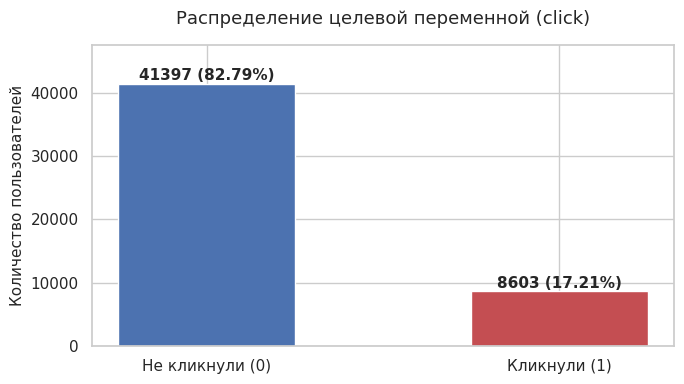

In [15]:
click_counts = df["click"].value_counts()
click_percentages = df["click"].value_counts(normalize=True) * 100

click_stats = pd.DataFrame(
    {
        "Количество (чел.)": click_counts,
        "Доля (%)": click_percentages.round(2),
    }
)
click_stats.index = click_stats.index.map(
    {0: "Не кликнули (0)", 1: "Кликнули (1)"}
)
display(click_stats)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    click_stats.index,
    click_stats["Количество (чел.)"],
    color=["#4C72B0", "#C44E52"],
    width=0.5,
)

for bar, pct in zip(bars, click_stats["Доля (%)"]):
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 100,
        f"{int(yval)} ({pct}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title("Распределение целевой переменной (click)", fontsize=13, pad=15)
ax.set_ylabel("Количество пользователей", fontsize=11)
ax.set_ylim(0, max(click_counts) * 1.15)
plt.tight_layout()
plt.show()

Дисбаланс классов определенно есть. Наблюдается, что на рекламу кликает малая доля пользователей - 17%.

In [16]:
categorical_cols = df.select_dtypes(include=['category', 'object', 'string']).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}\n")

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Числовые признаки: {numeric_cols}")

Категориальные признаки: ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'ml_feature_2', 'ml_feature_7']

Числовые признаки: ['id', 'click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


Но некоторые числовые признаки могут представлять собой категориальные, уже закодированные в числа. Это стоит учесть в будущем.

На данный момент бесполезным признаком можно назвать `id` — уникальный идентификатор записи о показе баннера, не несущий никакой полезной информации. О полезности остальных признаков пока говорить рано. Многие из них зашифрованы, но могут иметь сильное влияние на целевую переменную.

In [17]:
df = df.drop(columns=['id'])
df.head()

,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [18]:
missing_percentage = df.isna().mean() * 100

print(missing_percentage)

click               0.0
hour                0.0
C1                  0.0
banner_pos          0.0
site_id             0.0
site_domain         0.0
site_category       0.0
app_id              0.0
app_domain          0.0
app_category        0.0
device_id           0.0
device_ip           0.0
device_model        0.0
device_type         0.0
device_conn_type    0.0
C14                 0.0
C15                 0.0
C16                 0.0
C17                 0.0
C18                 0.0
C19                 0.0
C20                 0.0
C21                 0.0
ml_feature_1        0.0
ml_feature_2        0.0
ml_feature_3        0.0
ml_feature_4        0.0
ml_feature_5        0.0
ml_feature_6        0.0
ml_feature_7        0.0
ml_feature_8        0.0
ml_feature_9        0.0
ml_feature_10       0.0
dtype: float64


Еще при первичном изучении данных было заметно, что пропуски отсутствуют. Но это не значит, что в конечном пайплайне можно обойтись без обработчика. Новые данные могут содержать пропуски.

Числовые признаки лучше заполнять медианой, устойчивой к отклонениям.
Категориальные стоит заполнять наиболее частым значением для избежания сложностей с предобработкой. 

In [19]:
cat_unique = df.select_dtypes(include=['object', 'category']).nunique()
print(cat_unique)

site_id           1160
site_domain       1013
site_category       18
app_id             976
app_domain          67
app_category        22
device_id         8580
device_ip        41455
device_model      2521
ml_feature_2         5
ml_feature_7         3
dtype: int64


In [20]:
num_unique = df.select_dtypes(include=['number']).nunique()
print(num_unique)

click                   2
hour                  240
C1                      7
banner_pos              7
device_type             4
device_conn_type        4
C14                  1497
C15                     8
C16                     9
C17                   387
C18                     4
C19                    64
C20                   149
C21                    59
ml_feature_1        50000
ml_feature_3        50000
ml_feature_4            2
ml_feature_5        50000
ml_feature_6        50000
ml_feature_8        50000
ml_feature_9        50000
ml_feature_10       50000
dtype: int64


Признаки устройств пользователей имеют крайне много уникальных значений, их использование в модели может привести к переобучению. Поэтому скорее всего стоит удалить `device_id`, `device_ip`. Признаки `ml_feature_7`, `ml_feature_2`, `app_category`, `site_category` вполне можно кодировать с помощью One-Hot Encoding. Для остальных признаков более подходящим будет TargetEncoder.

Возможно, среди числовых признаков есть скрытые категориальные. Имеющие до 25 уникальных значений можно кодировать One-Hot Encoding, остальные TargetEncoder.

In [21]:
df = df.drop(columns=['device_id', 'device_ip'])

In [22]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

In [23]:
def get_outlier_summary(data, columns):
    result = []

    for col in columns:
        values = data[col].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = (
            (values < lower_bound)
            | (values > upper_bound)
        )

        result.append({
            "feature": col,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outliers_count": outliers.sum(),
            "outliers_share": outliers.mean()
        })

    return pd.DataFrame(result)


outlier_summary = get_outlier_summary(df, numeric_cols)

display(
    outlier_summary.sort_values(
        "outliers_share",
        ascending=False
    )
)

,feature,lower_bound,upper_bound,outliers_count,outliers_share
11,C19,-1.690000e+02,3.750000e+02,9015,0.18030
0,click,0.000000e+00,0.000000e+00,8603,0.17206
5,device_conn_type,0.000000e+00,0.000000e+00,6979,0.13958
9,C17,7.685000e+02,3.580500e+03,4224,0.08448
6,C14,9.426000e+03,2.941000e+04,4170,0.08340
2,C1,1.005000e+03,1.005000e+03,4165,0.08330
4,device_type,1.000000e+00,1.000000e+00,3969,0.07938
7,C15,3.200000e+02,3.200000e+02,3213,0.06426
8,C16,5.000000e+01,5.000000e+01,2713,0.05426
20,ml_feature_9,-1.321420e+00,1.391495e+00,387,0.00774


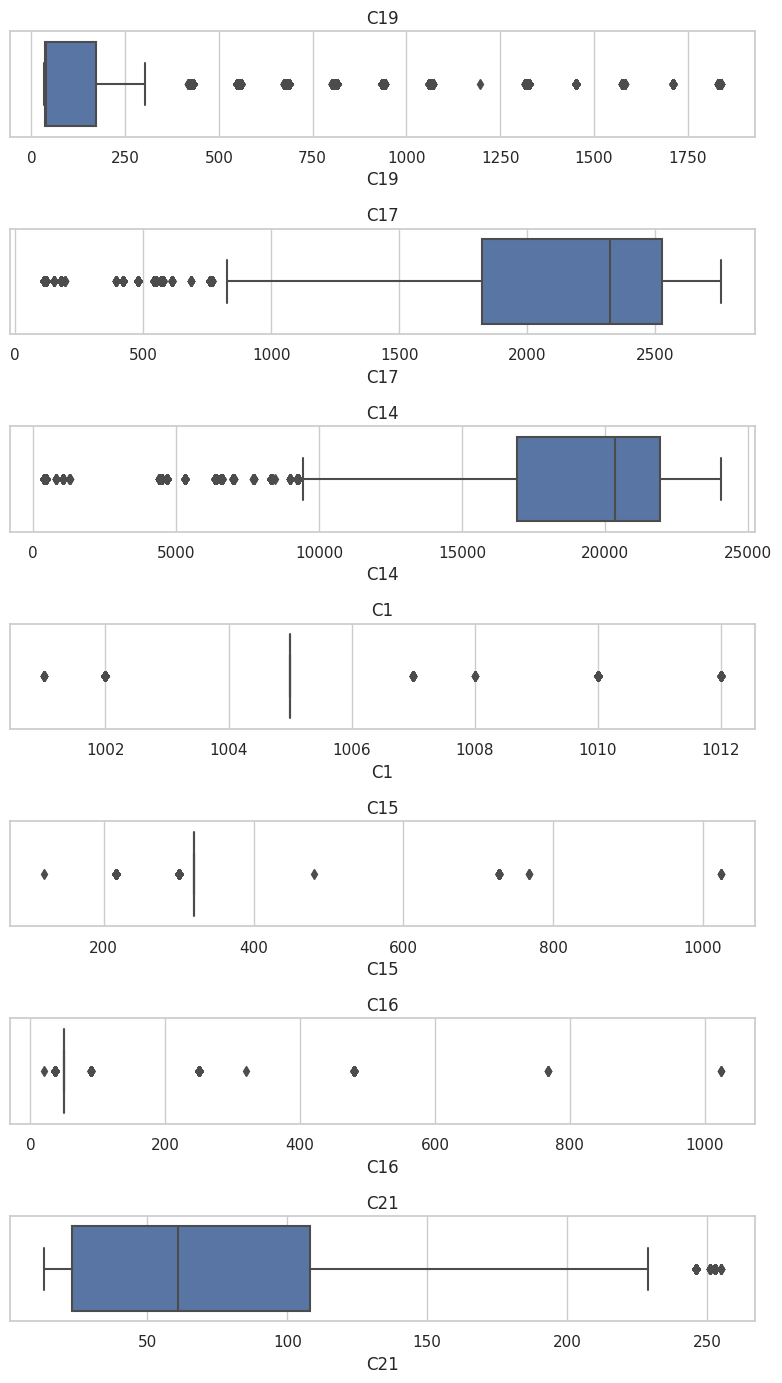

In [24]:
C_cols = [
    "C19",
    "C17",
    "C14",
    "C1",
    "C15",
    "C16",
    "C21"
]

fig, axes = plt.subplots(7, 1, figsize=(8, 14))

for ax, col in zip(axes.flat, C_cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

У анонимизированных признаков выбросы распределенны по-разному: где-то преимущественно под нижней границей, где-то наборот. Вероятно `C1`, `C15`, `C16` представляют собой категориальные коды.

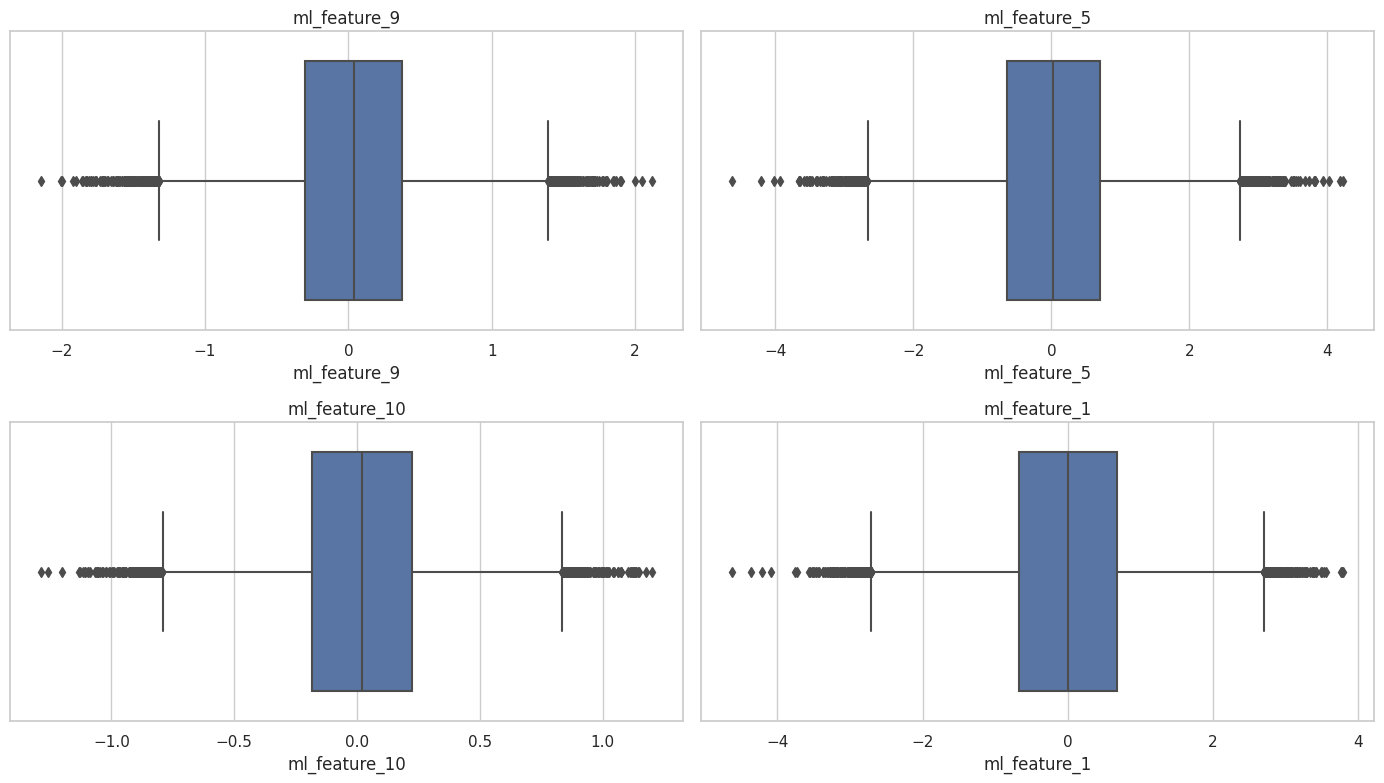

In [25]:
ml_cols = [
    "ml_feature_9",
    "ml_feature_5",
    "ml_feature_10",
    "ml_feature_1"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flat, ml_cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

У машинных признаков распределение выбросов выглядит симметричным.

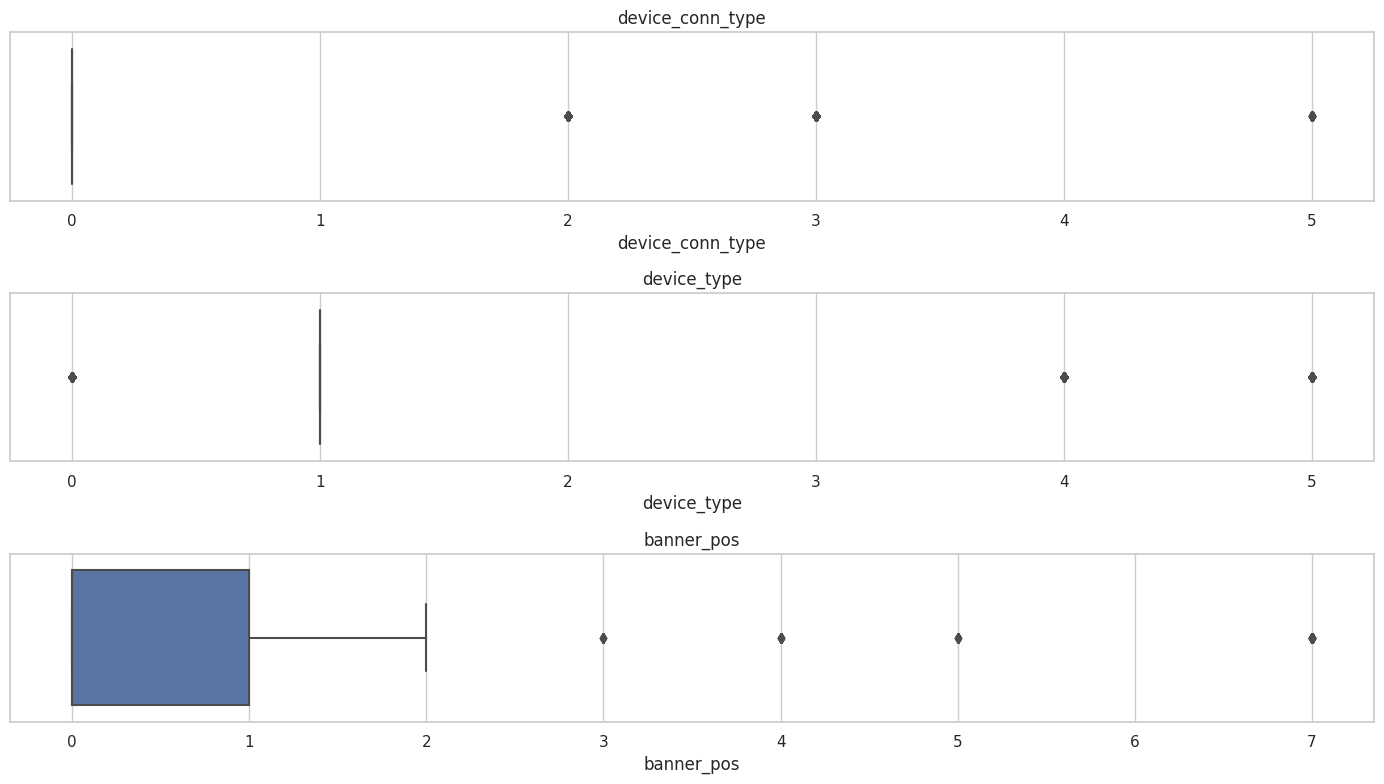

In [26]:
other_cols = [
    "device_conn_type",
    "device_type",
    "banner_pos"
]

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for ax, col in zip(axes.flat, other_cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Данные признаки имеют не совсем выбросы, т.к. они ближе по смыслу к категориальным. Некоторые значения встречаются чаще других.

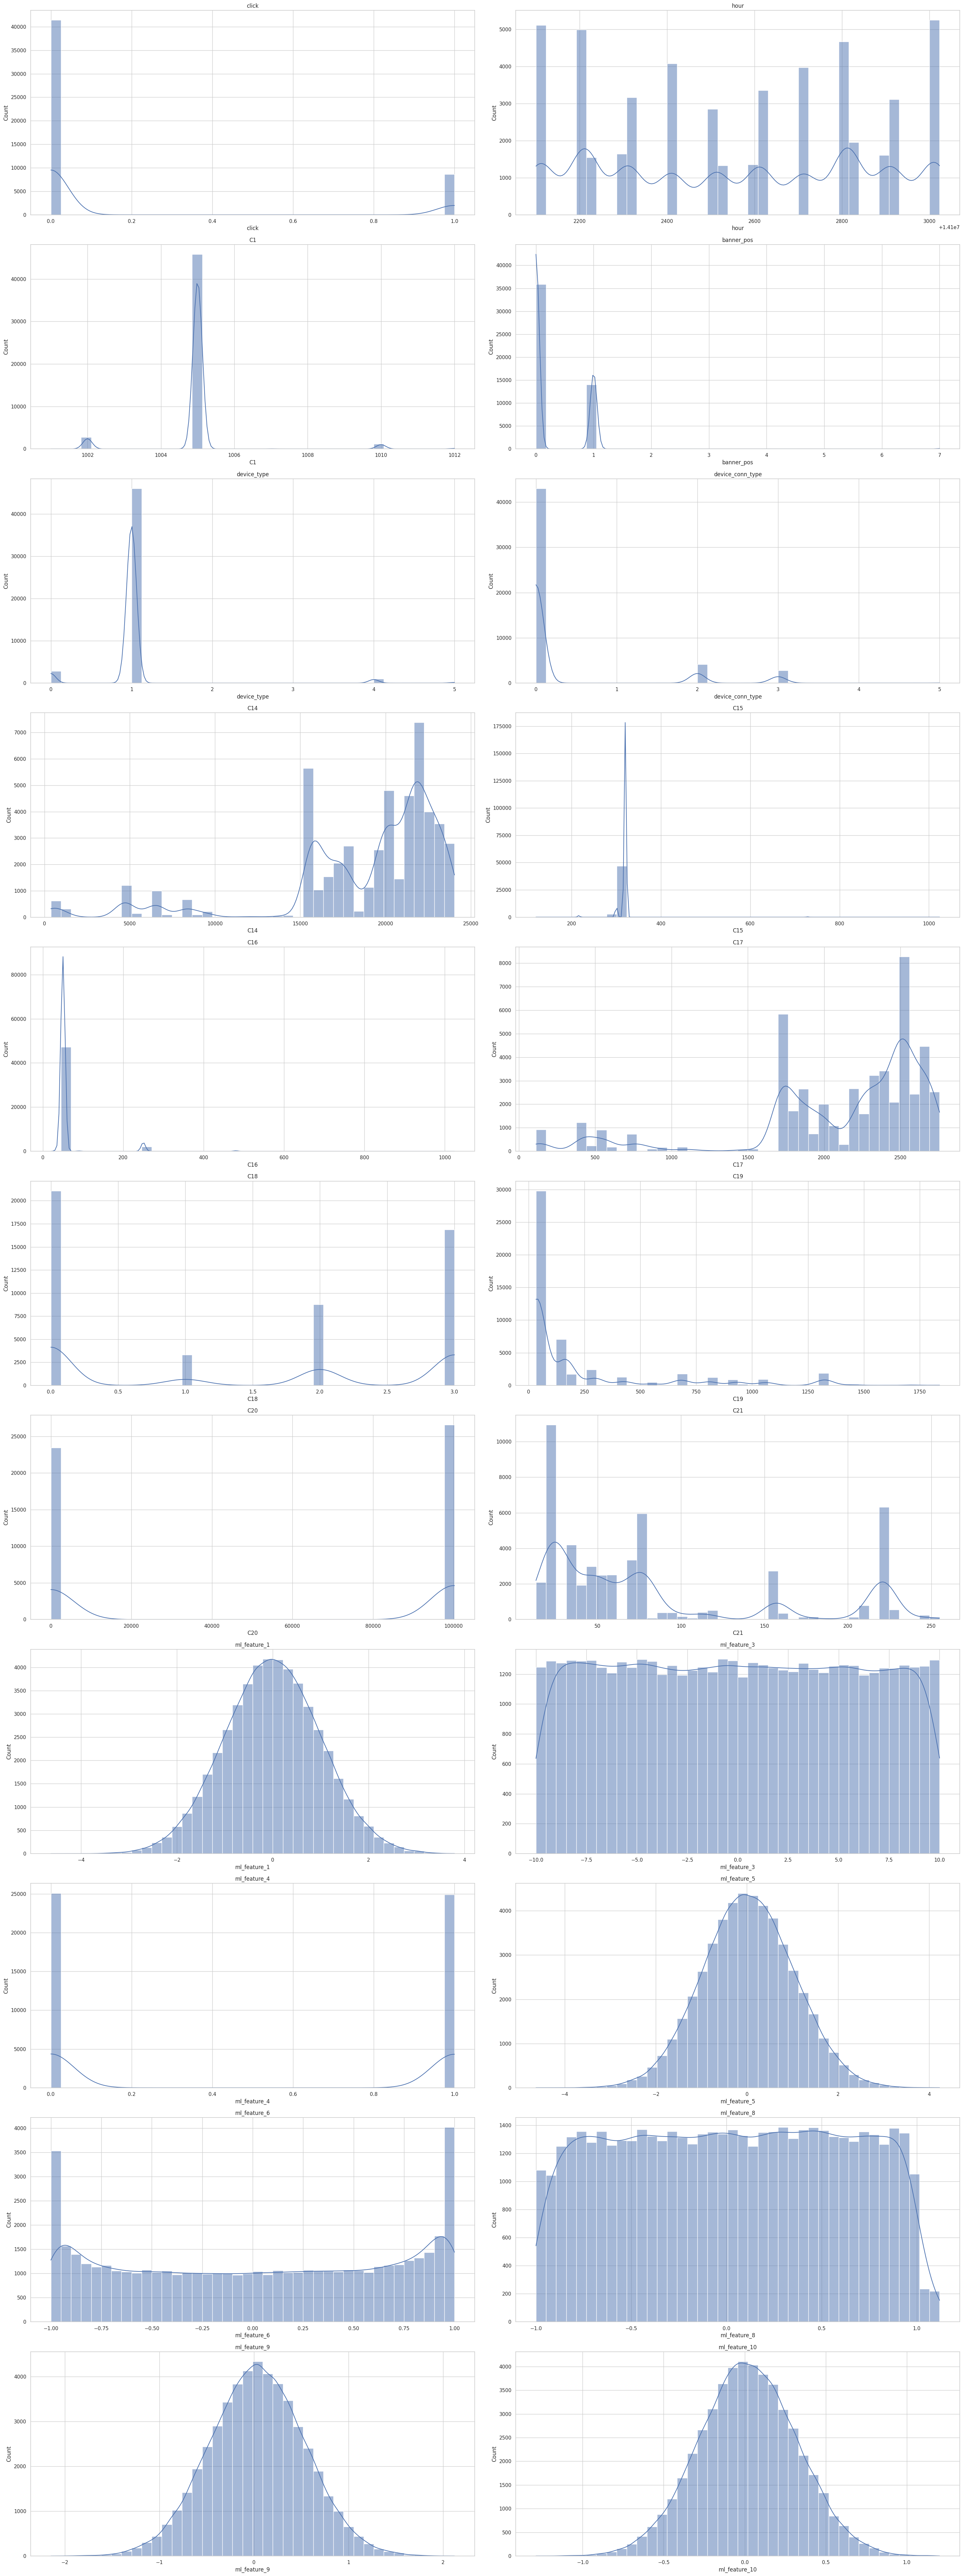

In [27]:
fig, axes = plt.subplots(11, 2, figsize=(30, 80))
axes = axes.flatten()

for col, ax in zip(numeric_cols, axes):
    sns.histplot(
        data=df,
        x=col,
        bins=40,
        kde=True,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [28]:
correlation_matrix = df.corr(method='pearson')
target_corr = correlation_matrix['click'].sort_values(ascending=False)
print(target_corr)

click               1.000000
ml_feature_9        0.145883
ml_feature_10       0.130906
C16                 0.129796
ml_feature_8        0.080062
ml_feature_6        0.071566
ml_feature_5        0.062550
banner_pos          0.025069
C18                 0.022078
ml_feature_3        0.002935
ml_feature_1        0.002054
C19                -0.000178
ml_feature_4       -0.003141
hour               -0.014466
C15                -0.030018
device_type        -0.043879
C1                 -0.047655
C20                -0.048712
C17                -0.057804
C14                -0.064033
C21                -0.064706
device_conn_type   -0.081364
Name: click, dtype: float64


In [29]:
correlation_matrix = df.corr(method='spearman')
target_corr = correlation_matrix['click'].sort_values(ascending=False)
print(target_corr)

click               1.000000
ml_feature_9        0.140747
C16                 0.130813
ml_feature_10       0.126674
ml_feature_8        0.077923
ml_feature_6        0.071870
ml_feature_5        0.060347
banner_pos          0.023058
C18                 0.008595
ml_feature_3        0.002936
ml_feature_1        0.000867
ml_feature_4       -0.003141
C19                -0.012409
hour               -0.014598
device_type        -0.047774
C1                 -0.048757
C20                -0.064544
C17                -0.064827
C14                -0.072136
device_conn_type   -0.076268
C21                -0.084017
C15                -0.112777
Name: click, dtype: float64


# phik матрица вычисляется очень долго, поэтому ниже продублированы полученные визуализации.

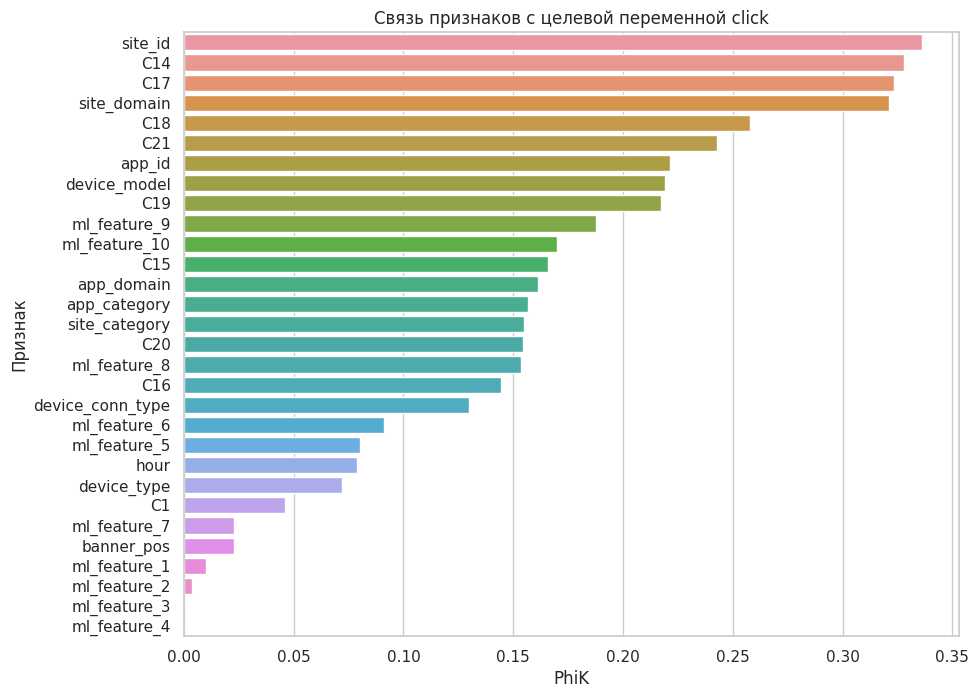

Больше всего с целевой переменной коррелируют `site_id`, `C14`, `C17`, `site_domain`, `C18`, `C21`, `app_id`, `device_model`, `C19`, `ml_feature_9`.
Признаки `ml_feature_4`, `ml_feature_3`, `ml_feature_2`, `ml_feature_1`, `banner_pos`, `ml_feature_7`, `C1` очень слабо связаны с целевой переменной.

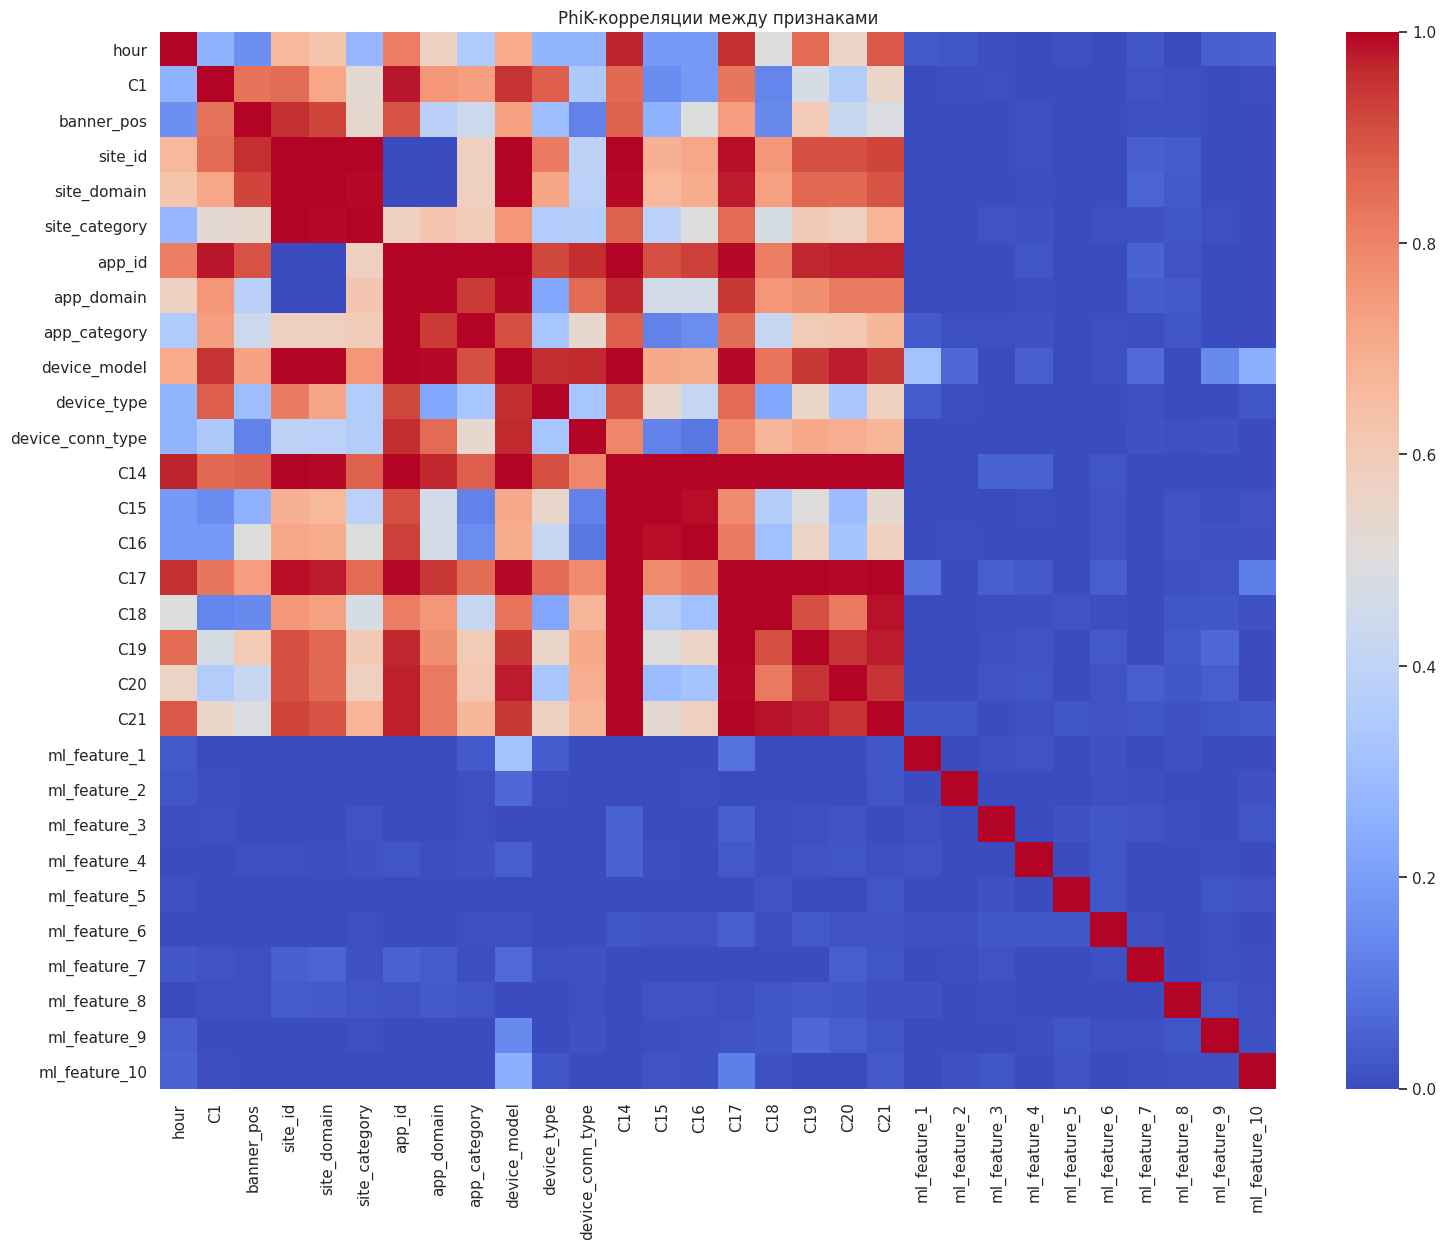

Замечены сильно скоррелированные признаки. Как видно, `app_id`, `device_model`, `C14`, `C17` коррелирую с большим количеством других признаков. Также заметны "квадраты" высокой корреляции: группа `C17-C21`, группа `C14-C16`, группа `site_id, site_domain, site_category`, группа `app_id, app_domain, app_category, device_model`. Из каждой группы можно оставить один наиболее полезный для модели признак, чтобы избежать мультиколлинеарности.

#### Выводы по EDA

- **Базовая информация о датасете:** Выявлено 34 признака, всего 50000 записей; присутствуют числовые и категориальные признаки, при этом некоторые числовые могут нести категориальные смысл; признаки включат в себя информацию о пользователе, сайте, рекламе, скрытых данных баннера/аукциона, сгенерированных машинных (ML) характеристиках. 
- **Анализ целевой переменной:** Положительный класс целевой переменной встречается всего в 17.21% записей, что указывает на дисбаланс классов.
- **Анализ признаков:** Явно бесполезным для модели выявлен признак `id` — уникальный идентификатор записи о показе баннера; остальные лишние признаки могут быть выявлены на этапе feature_selection.
- **Анализ пропущенных значений:** Пропущенных значений в датасете нет, но предобработка пропущенных значений необходима в пайплайне; пропущенные категориальные значения могут обозначены меткой `missing`, а числовые могут быть представлены медианой.
- **Анализ категориальных признаков:** Среди категориальных признаков присутствуют подходящие для One-Hot Encoding или для Target Encoding, но также присутствуют высоко кардинальные, претендующие на удаление.
- **Анализ выбросов и распределений:** Некоторые числовые признаки имеют явные выбросы, причем они бывают симметричные и ассиметричные, необычного вида; это указывает на подтверждение гипотезы о числовых признаках с категориальным смыслом.
- **Корреляции:** С помощью phik, способного обрабатывать категориальные и числовые признаки, выявлены наиболее влияющие на целевую переменную; также проанализированная взаимная коллинеарность признаков, указавшая на возможную проблему мультиколлинеарности.

Наиболее перспективными для модели могут стать признаки `site_id`, `C14`, `C17`, `site_domain`, `C18`, `C21`, `app_id`, `device_model`, `C19`, `ml_feature_9`, имеющие значимую коллинеарность с целевой переменной согласно анализу по phik.

Предобработка данных:
- Удаление: `id`, `device_id`, `device_ip` могут привести к переобучению модели, поэтому их нужно удалить.
- Работа с пропусками: явные категориальные и скрытные категориальные стоит заменять частым значением; числовые значения будут заменяться медианой.
- Масштабирование: для числовых будет использоваться StandardScaler.
- Кодирование категорий: категории с малым количеством уникальных значений будут кодироваться One-Hot Encoder, остальные с помощью Target Encoder; учитываем числовые признаки со смыслом категориальных.
- Возможный feature engineering: из `hours` в отдельные признаки можно вычленить день и час показа рекламы.

## 3. Разделение данных на выборки

In [30]:
X = df.drop(columns=['click'])
y = df['click']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

In [31]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

0    0.82795
1    0.17205
Name: click, dtype: float64
0    0.8279
1    0.1721
Name: click, dtype: float64


In [32]:
print(f"Train: {X_train.shape[0]}")
print(f"Test: {X_test.shape[0]}")  

Train: 40000
Test: 10000


Распределение сохранилось, выборки разбились корректно.

## 4. Предобработка данных — построение пайплайнов

In [33]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_oh = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_transformer_tr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder())
])

Для числовых признаков происходит заполнение пропусков медианой, масштабирование с помощью StandardScaler. Не кардинальные категориальные признаки кодируются OneHotEncoder. Кардинальные категориальные признаки кодируются TargetEncoder.

In [34]:
num_all = ['ml_feature_1', 'ml_feature_3', 'ml_feature_5',
          'ml_feature_6', 'ml_feature_8', 'ml_feature_9',
          'ml_feature_10'
          ]
cat_oh = ['ml_feature_2', 'ml_feature_7', 'app_category',
          'site_category', 'C1', 'banner_pos',
          'device_type', 'device_conn_type', 'C15',
         'C16', 'C18', 'ml_feature_4', 'hour'
         ]
cat_tr = ['site_id', 'site_domain', 'app_id',
         'app_domain', 'device_model', 'C17',
         'C19', 'C20', 'C21',
         'C14'
         ]

In [35]:
column_preprocessor = ColumnTransformer(
transformers=[
    ('num', numeric_transformer, num_all),
    ('cat_oh', categorical_transformer_oh, cat_oh),
    ('cat_tr', categorical_transformer_tr, cat_tr)
], remainder='drop'
)

preprocessing_pipeline = Pipeline(steps=[
    ('column_preprocessor', column_preprocessor)
])

print(preprocessing_pipeline)

Pipeline(steps=[('column_preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ml_feature_1',
                                                   'ml_feature_3',
                                                   'ml_feature_5',
                                                   'ml_feature_6',
                                                   'ml_feature_8',
                                                   'ml_feature_9',
                                                   'ml_feature_10']),
                                                 ('cat_oh',
                          

Создан единый пайплайн предобработки `preprocessing_pipeline`, включающий в себя небольшой feature engineering.

## 5. Отбор признаков

In [37]:
X_train_fe = X_train
train_for_selection = X_train_fe.copy()
train_for_selection['click'] = y_train.values

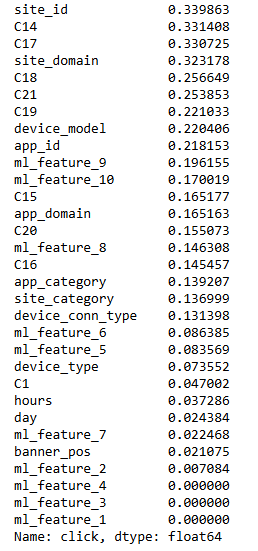

Топ лучших признаков: `ml_feature_9`, `app_id`, `device_model`, `C19`, `C21`, `C18`, `site_domain`, `C17`, `C14`, `site_id`. Они находятся в диапазоне корреляции с целевой переменной ~0.2-0.34, что выделяет их по сравнению с остальными признаками.

In [38]:
top_filter_features = ['ml_feature_9', 'app_id', 'device_model', 'C19', 'C21', 'C18', 'site_domain', 'C17', 'C14', 'site_id']

In [39]:
num_fs = [
    col for col in num_all
    if col in top_filter_features
]

cat_oh_fs = [
    col for col in cat_oh
    if col in top_filter_features
]

cat_tr_fs = [
    col for col in cat_tr
    if col in top_filter_features
]

print('Числовые:', num_fs)
print('OHE:', cat_oh_fs)
print('Target Encoding:', cat_tr_fs)

Числовые: ['ml_feature_9']
OHE: ['C18']
Target Encoding: ['site_id', 'site_domain', 'app_id', 'device_model', 'C17', 'C19', 'C21', 'C14']


In [40]:
column_preprocessor_fs = ColumnTransformer(
    transformers=[
        ('num', clone(numeric_transformer), num_fs),
        ('cat_oh', clone(categorical_transformer_oh), cat_oh_fs),
        ('cat_tr', clone(categorical_transformer_tr), cat_tr_fs)
    ],
    remainder='drop'
)

preprocessing_pipeline_fs = Pipeline(
    steps=[
        ('column_preprocessor', column_preprocessor_fs)
    ]
)

In [41]:
X_train_pp = preprocessing_pipeline_fs.fit_transform(
    X_train,
    y_train
)

print(X_train.shape)
print(X_train_pp.shape)

(40000, 30)
(40000, 13)


In [42]:
ct = preprocessing_pipeline_fs.named_steps['column_preprocessor']

num_names = list(num_fs)

ohe = (
    ct
    .named_transformers_['cat_oh']
    .named_steps['onehot']
)

ohe_names = []

for feature, categories in zip(cat_oh_fs, ohe.categories_):
    for category in categories:
        ohe_names.append(f'{feature}_{category}')


target_names = list(cat_tr_fs)

feature_names = np.array(
    num_names
    + ohe_names
    + target_names
)

print(feature_names)
print('Количество названий:', len(feature_names))
print('Количество столбцов:', X_train_pp.shape[1])

['ml_feature_9' 'C18_0' 'C18_1' 'C18_2' 'C18_3' 'site_id' 'site_domain'
 'app_id' 'device_model' 'C17' 'C19' 'C21' 'C14']
Количество названий: 13
Количество столбцов: 13


In [43]:
variance_filter = VarianceThreshold(
    threshold=0.0
)

X_train_vt = variance_filter.fit_transform(
    X_train_pp
)

variance_df = pd.DataFrame({
    'feature': feature_names,
    'variance': variance_filter.variances_
}).sort_values('variance')

display(variance_df)

,feature,variance
7,app_id,0.003837
8,device_model,0.004055
10,C19,0.004481
11,C21,0.005976
6,site_domain,0.008635
5,site_id,0.009584
12,C14,0.009953
9,C17,0.010128
2,C18_1,0.061969
3,C18_2,0.145332


In [44]:
vt_feature_names = feature_names[
    variance_filter.get_support()
]

print(
    f'До VarianceThreshold: {len(feature_names)}'
)

print(
    f'После VarianceThreshold: {len(vt_feature_names)}'
)

print(vt_feature_names)

До VarianceThreshold: 13
После VarianceThreshold: 13
['ml_feature_9' 'C18_0' 'C18_1' 'C18_2' 'C18_3' 'site_id' 'site_domain'
 'app_id' 'device_model' 'C17' 'C19' 'C21' 'C14']


После кодирования к признакам применён VarianceThreshold. При пороге 0 удаляются константные признаки, которые не содержат информации для классификации. Если таких признаков не обнаружено, исходный набор после данного этапа сохраняется.

In [45]:
selector_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_SEED
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [46]:
rfecv = RFECV(
    estimator=selector_model,
    step=1,
    cv=cv,
    scoring='average_precision',
    min_features_to_select=2,
    n_jobs=-1
)

rfecv.fit(
    X_train_vt,
    y_train
)

RFECV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
      estimator=LogisticRegression(max_iter=2000, random_state=42),
      min_features_to_select=2, n_jobs=-1, scoring='average_precision')

In [47]:
print(
    'Оптимальное количество признаков:',
    rfecv.n_features_
)

rfecv_features = vt_feature_names[
    rfecv.support_
]

display(rfecv_features)

Оптимальное количество признаков: 12


array(['ml_feature_9', 'C18_0', 'C18_1', 'C18_3', 'site_id',
       'site_domain', 'app_id', 'device_model', 'C17', 'C19', 'C21',
       'C14'], dtype='<U12')

# SFS выполняется очень долго

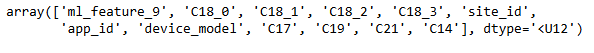

Для отбора признаков применены методы-обертки `Recursive Feature Elimination with Cross-Validation` и `Sequential Feature Selector`, реализованные на основе логистической регрессии.

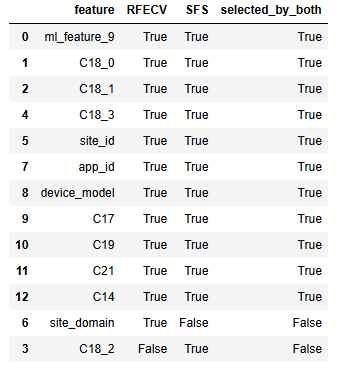

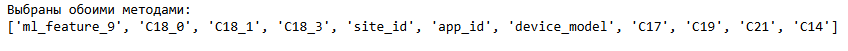

In [48]:
final_features = [
    'ml_feature_9',
    'C18',
    'site_id',
    'app_id',
    'device_model',
    'C17',
    'C19',
    'C21',
    'C14'
]

In [49]:
num_final = [
    col for col in num_all
    if col in final_features
]

cat_oh_final = [
    col for col in cat_oh
    if col in final_features
]

cat_tr_final = [
    col for col in cat_tr
    if col in final_features
]

print('Числовые:', num_final)
print('OHE:', cat_oh_final)
print('Target Encoding:', cat_tr_final)

Числовые: ['ml_feature_9']
OHE: ['C18']
Target Encoding: ['site_id', 'app_id', 'device_model', 'C17', 'C19', 'C21', 'C14']


In [50]:
final_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_final),
        ('cat_oh', categorical_transformer_oh, cat_oh_final),
        ('cat_tr', categorical_transformer_tr, cat_tr_final)
    ],
    remainder='drop'
)

Отобранные признаки теперь будут применяться для обучения последующих моделей.

## 6. Обучение базовой модели

In [51]:
dummy_model = DummyClassifier(
    strategy='prior'
)

In [52]:
X_dummy = np.zeros((len(y_train), 1))

In [53]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [54]:
scoring = {
    'pr_auc': 'average_precision',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

In [55]:
dummy_cv = cross_validate(
    dummy_model,
    X_dummy,
    y_train,
    cv=cv,
    scoring=scoring
)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined a

In [56]:
print(
    'Dummy PR-AUC:',
    dummy_cv['test_pr_auc'].mean()
)

Dummy PR-AUC: 0.17204999999999998


Положительный класс составляет примерно 17%, поэтому для такого baseline PR-AUC будет находиться примерно в районе доли положительного класса.

In [57]:
logreg_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_SEED
    ))
])

In [58]:
logreg_cv = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

In [59]:
print(
    'LogisticRegression PR-AUC:',
    logreg_cv['test_pr_auc'].mean()
)

print(
    'Std:',
    logreg_cv['test_pr_auc'].std()
)

LogisticRegression PR-AUC: 0.3670023034476506
Std: 0.006602823189268386


In [60]:
svc_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', SVC(
        kernel='linear',
        probability=False,
        random_state=RANDOM_SEED
    ))
])

In [61]:
svc_cv = cross_validate(
    svc_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined a

In [62]:
print(
    'SVC PR-AUC:',
    svc_cv['test_pr_auc'].mean()
)

print(
    'Std:',
    svc_cv['test_pr_auc'].std()
)

SVC PR-AUC: 0.330385127955733
Std: 0.011451038806452847


In [63]:
def cv_summary(name, cv_result):
    return {
        'model': name,
        'PR-AUC_mean': cv_result['test_pr_auc'].mean(),
        'PR-AUC_std': cv_result['test_pr_auc'].std(),
        'Precision': cv_result['test_precision'].mean(),
        'Recall': cv_result['test_recall'].mean(),
        'F1': cv_result['test_f1'].mean()
    }

In [64]:
results = pd.DataFrame([
    cv_summary('DummyClassifier', dummy_cv),
    cv_summary('LogisticRegression', logreg_cv),
    cv_summary('SVC linear', svc_cv)
])

display(
    results.sort_values(
        'PR-AUC_mean',
        ascending=False
    )
)

,model,PR-AUC_mean,PR-AUC_std,Precision,Recall,F1
1,LogisticRegression,0.367002,0.006603,0.531463,0.116536,0.190935
2,SVC linear,0.330385,0.011451,0.000000,0.000000,0.000000
0,DummyClassifier,0.172050,0.000061,0.000000,0.000000,0.000000


При текущих настройках SVC на несбалансированной выборке ни один объект не оказался по положительную сторону порога: predicted class = 0 для всех. Поэтому: Recall = 0, F1 = 0.

По результатам пятифолдовой кросс-валидации обе обученные модели превосходят базовый DummyClassifier по PR-AUC. LogisticRegression показала наилучший результат - 0.367 +- 0.006 против 0.330 +- 0.011 у линейного SVC и 0.172 у DummyClassifier. На данном этапе LogisticRegression является наиболее качественной базовой моделью.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

In [65]:
logreg_grid = {
    'model__solver': ['liblinear'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__class_weight': [None, 'balanced']
}

In [66]:
svc_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': [None, 'balanced']
}

Лучшие параметры LogisticRegression:
{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Лучший CV PR-AUC: 0.3736549132249504

# svc_search очень долгий

Лучшие параметры SVC:
{'model__C': 0.01, 'model__class_weight': 'balanced'}
Лучший CV PR-AUC: 0.37142594768672055

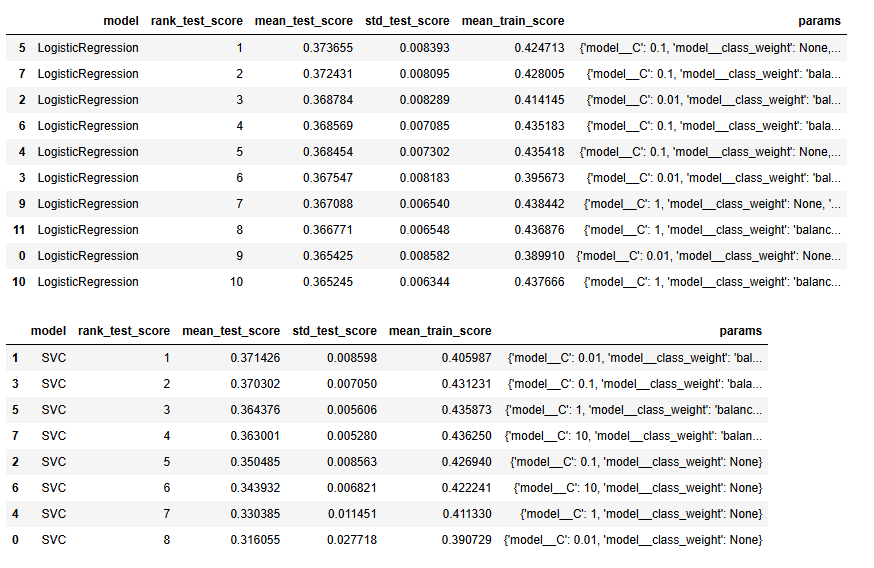

## 8. Финальная модель

In [67]:
best_logreg_params = {
    'model__C': 0.1,
    'model__class_weight': None,
    'model__penalty': 'l2',
    'model__solver': 'liblinear'
}

best_svc_params = {
    'model__C': 0.01,
    'model__class_weight': 'balanced'
}

In [68]:
final_logreg = clone(logreg_pipeline).set_params(
    **best_logreg_params
)

final_svc = clone(svc_pipeline).set_params(
    **best_svc_params
)

In [69]:
final_logreg.fit(X_train, y_train)
final_svc.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ml_feature_9']),
                                                 ('cat_oh',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['C18']),
  

In [70]:
logreg_proba = final_logreg.predict_proba(
    X_test
)[:, 1]

logreg_pred = final_logreg.predict(
    X_test
)

In [71]:
svc_scores = final_svc.decision_function(
    X_test
)

svc_pred = final_svc.predict(
    X_test
)

In [72]:
svc_proba = expit(svc_scores)

In [73]:
def test_metrics(
    model_name,
    y_true,
    y_score,
    y_proba,
    y_pred
):
    return {
        'model': model_name,
        'PR-AUC': average_precision_score(
            y_true,
            y_score
        ),
        'Brier': brier_score_loss(
            y_true,
            y_proba
        ),
        'Precision': precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        'F1': f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

In [74]:
logreg_metrics = test_metrics(
    model_name='LogisticRegression',
    y_true=y_test,
    y_score=logreg_proba,
    y_proba=logreg_proba,
    y_pred=logreg_pred
)

In [75]:
svc_metrics = test_metrics(
    model_name='SVC',
    y_true=y_test,
    y_score=svc_scores,
    y_proba=svc_proba,
    y_pred=svc_pred
)

In [76]:
test_results = pd.DataFrame([
    logreg_metrics,
    svc_metrics
])

display(
    test_results.sort_values(
        'PR-AUC',
        ascending=False
    )
)

,model,PR-AUC,Brier,Precision,Recall,F1
0,LogisticRegression,0.348556,0.129872,0.531353,0.093550,0.159091
1,SVC,0.347301,0.210254,0.293094,0.636258,0.401319


In [77]:
cv_test_comparison = pd.DataFrame({
    'model': [
        'LogisticRegression',
        'SVC'
    ],

    'CV_PR-AUC': [
        0.3736549132249504,
        0.37142594768672055
    ],

    'Test_PR-AUC': [
        logreg_metrics['PR-AUC'],
        svc_metrics['PR-AUC']
    ]
})

cv_test_comparison['difference'] = (
    cv_test_comparison['Test_PR-AUC']
    - cv_test_comparison['CV_PR-AUC']
)

display(cv_test_comparison)

,model,CV_PR-AUC,Test_PR-AUC,difference
0,LogisticRegression,0.373655,0.348556,-0.025099
1,SVC,0.371426,0.347301,-0.024125


Видно, что регрессия обладает высокой `Precision` и низиким `Recall`, что выражается в низкой `F1`. У опорных векторов ситуация другая, между метриками наблюдается больший баланс, что улучшает F1-метрику. `PR-AUC` немного лучше у логистической регрессии, как и Brier Score.

In [78]:
def get_feature_names_from_pipeline(
    fitted_pipeline,
    num_features,
    ohe_features,
    target_features
):
    preprocessor = (
        fitted_pipeline
        .named_steps['preprocessor']
    )

    feature_names = []

    feature_names.extend(
        num_features
    )

    if len(ohe_features) > 0:

        ohe = (
            preprocessor
            .named_transformers_['cat_oh']
            .named_steps['onehot']
        )

        for feature, categories in zip(
            ohe_features,
            ohe.categories_
        ):
            for category in categories:
                feature_names.append(
                    f'{feature}_{category}'
                )

    feature_names.extend(
        target_features
    )

    return np.array(feature_names)

In [79]:
feature_names = get_feature_names_from_pipeline(
    fitted_pipeline=final_logreg,
    num_features=num_final,
    ohe_features=cat_oh_final,
    target_features=cat_tr_final
)

print(feature_names)

['ml_feature_9' 'C18_0' 'C18_1' 'C18_2' 'C18_3' 'site_id' 'app_id'
 'device_model' 'C17' 'C19' 'C21' 'C14']


In [80]:
logreg_coef = (
    final_logreg
    .named_steps['model']
    .coef_[0]
)

print(
    'Признаков:',
    len(feature_names)
)

print(
    'Коэффициентов:',
    len(logreg_coef)
)

assert len(feature_names) == len(logreg_coef)

Признаков: 12
Коэффициентов: 12


In [81]:
logreg_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logreg_coef,
    'abs_coefficient': np.abs(logreg_coef)
})

logreg_importance = (
    logreg_importance
    .sort_values(
        'abs_coefficient',
        ascending=False
    )
)

display(logreg_importance)

,feature,coefficient,abs_coefficient
7,device_model,4.059325,4.059325
6,app_id,3.079089,3.079089
5,site_id,3.027880,3.027880
11,C14,2.710971,2.710971
2,C18_1,-1.173662,1.173662
3,C18_2,-0.828099,0.828099
8,C17,0.810290,0.810290
1,C18_0,-0.721049,0.721049
4,C18_3,-0.706865,0.706865
0,ml_feature_9,0.407829,0.407829


In [82]:
display(
    logreg_importance.head(10)
)

,feature,coefficient,abs_coefficient
7,device_model,4.059325,4.059325
6,app_id,3.079089,3.079089
5,site_id,3.027880,3.027880
11,C14,2.710971,2.710971
2,C18_1,-1.173662,1.173662
3,C18_2,-0.828099,0.828099
8,C17,0.810290,0.810290
1,C18_0,-0.721049,0.721049
4,C18_3,-0.706865,0.706865
0,ml_feature_9,0.407829,0.407829


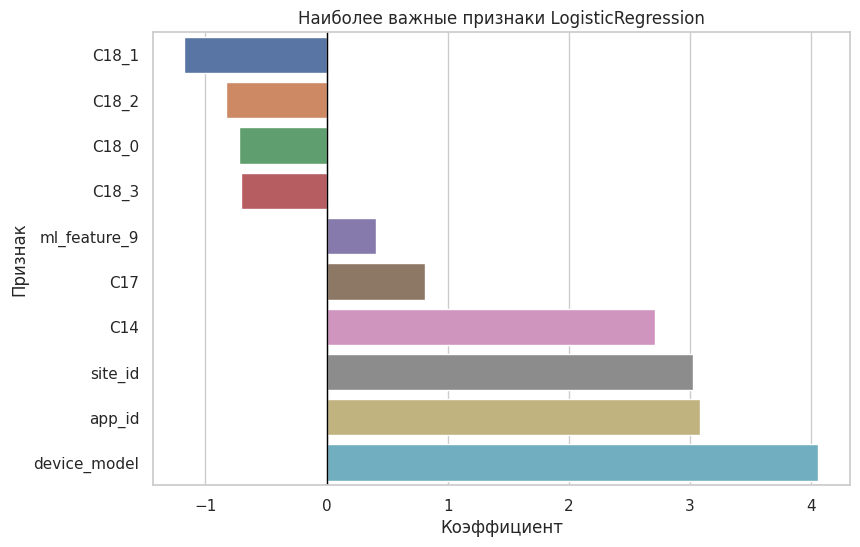

In [83]:
top_logreg = (
    logreg_importance
    .head(10)
    .sort_values('coefficient')
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_logreg,
    x='coefficient',
    y='feature'
)

plt.axvline(
    0,
    color='black',
    linewidth=1
)

plt.title(
    'Наиболее важные признаки LogisticRegression'
)

plt.xlabel('Коэффициент')
plt.ylabel('Признак')

plt.show()

In [84]:
svc_coef = (
    final_svc
    .named_steps['model']
    .coef_[0]
)

In [85]:
svc_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': svc_coef,
    'abs_coefficient': np.abs(svc_coef)
})

svc_importance = (
    svc_importance
    .sort_values(
        'abs_coefficient',
        ascending=False
    )
)

display(
    svc_importance.head(10)
)

,feature,coefficient,abs_coefficient
5,site_id,2.566457,2.566457
7,device_model,2.402681,2.402681
11,C14,2.171677,2.171677
6,app_id,1.861069,1.861069
8,C17,1.437466,1.437466
9,C19,0.466858,0.466858
0,ml_feature_9,0.459845,0.459845
10,C21,0.330907,0.330907
2,C18_1,-0.150136,0.150136
3,C18_2,0.072067,0.072067


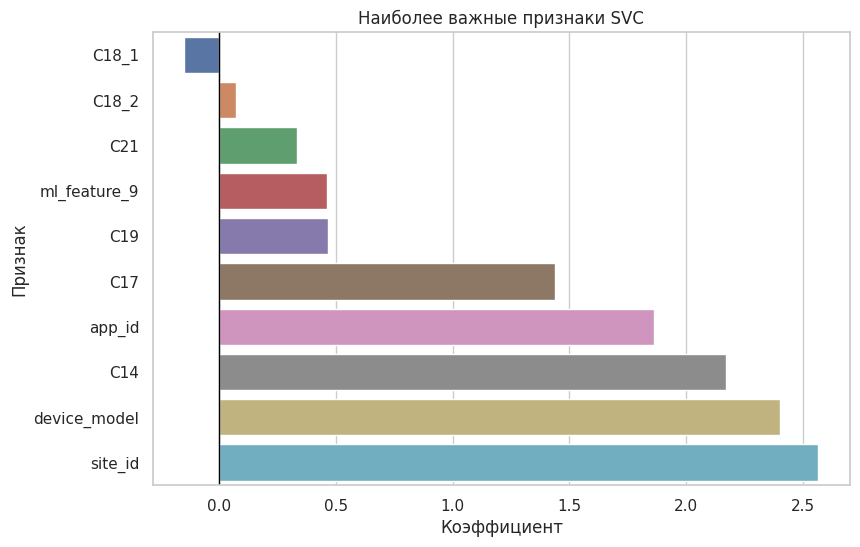

In [86]:
top_svc = (
    svc_importance
    .head(10)
    .sort_values('coefficient')
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_svc,
    x='coefficient',
    y='feature'
)

plt.axvline(
    0,
    color='black',
    linewidth=1
)

plt.title(
    'Наиболее важные признаки SVC'
)

plt.xlabel('Коэффициент')
plt.ylabel('Признак')

plt.show()

У `LogisticRegression` и `SVC` важность коэффициентов отличаются. Для регрессии наиболее важен `device_model`, а для опорных векторов `site_id`. 

## 9. Калибровка модели

In [87]:
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_SEED
)

print('Fit:', X_fit.shape)
print('Calibration:', X_calib.shape)

print(
    'Доля click в fit:',
    y_fit.mean()
)

print(
    'Доля click в calibration:',
    y_calib.mean()
)

Fit: (32000, 30)
Calibration: (8000, 30)
Доля click в fit: 0.1720625
Доля click в calibration: 0.172


In [88]:
calib_preprocessing = Pipeline([
    (
        'preprocessor',
        clone(final_preprocessor)
    )
])

In [89]:
X_fit_pp = calib_preprocessing.fit_transform(
    X_fit,
    y_fit
)

X_calib_pp = calib_preprocessing.transform(
    X_calib
)

X_test_pp = calib_preprocessing.transform(
    X_test
)

In [90]:
print('Fit:', X_fit_pp.shape)
print('Calibration:', X_calib_pp.shape)
print('Test:', X_test_pp.shape)

assert X_fit_pp.shape[1] == X_calib_pp.shape[1]
assert X_fit_pp.shape[1] == X_test_pp.shape[1]

Fit: (32000, 12)
Calibration: (8000, 12)
Test: (10000, 12)


In [91]:
base_logreg = clone(
    final_logreg.named_steps['model']
)

base_svc = clone(
    final_svc.named_steps['model']
)

In [92]:
base_logreg.fit(
    X_fit_pp,
    y_fit
)

base_svc.fit(
    X_fit_pp,
    y_fit
)

SVC(C=0.01, class_weight='balanced', kernel='linear', random_state=42)

In [93]:
logreg_before_proba = (
    base_logreg
    .predict_proba(X_test_pp)[:, 1]
)

In [94]:
svc_before_scores = (
    base_svc
    .decision_function(X_test_pp)
)

svc_before_proba = expit(
    svc_before_scores
)

In [95]:
logreg_true_before, logreg_pred_before = calibration_curve(
    y_test,
    logreg_before_proba,
    n_bins=10,
    strategy='quantile'
)

svc_true_before, svc_pred_before = calibration_curve(
    y_test,
    svc_before_proba,
    n_bins=10,
    strategy='quantile'
)

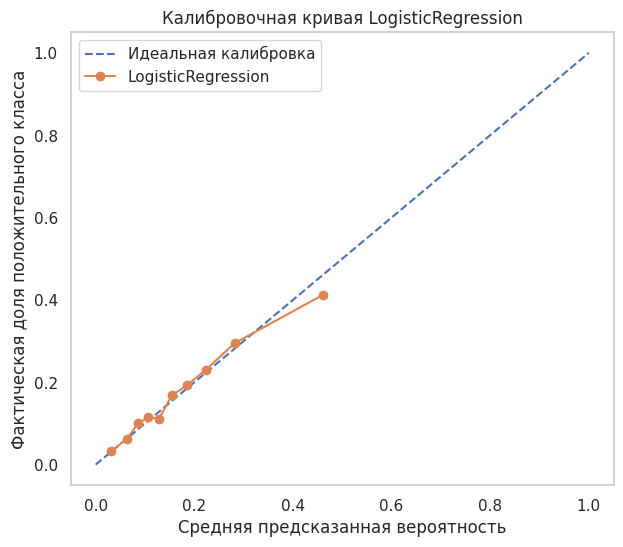

In [96]:
plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Идеальная калибровка'
)

plt.plot(
    logreg_pred_before,
    logreg_true_before,
    marker='o',
    label='LogisticRegression'
)

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая доля положительного класса')
plt.title('Калибровочная кривая LogisticRegression')
plt.legend()
plt.grid()

plt.show()

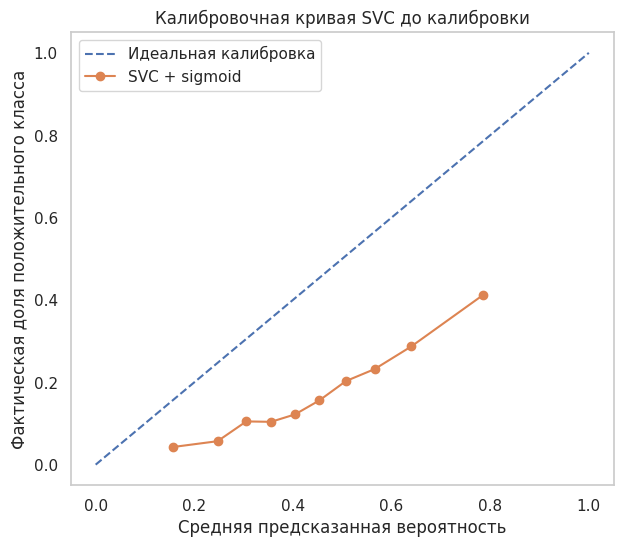

In [97]:
plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Идеальная калибровка'
)

plt.plot(
    svc_pred_before,
    svc_true_before,
    marker='o',
    label='SVC + sigmoid'
)

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая доля положительного класса')
plt.title('Калибровочная кривая SVC до калибровки')
plt.legend()
plt.grid()

plt.show()

Вероятности `LogisticRegression` близки к идеальной калибровке. А вероятности `SVC` переоценены.

In [98]:
calibrated_logreg = CalibratedClassifierCV(
    base_estimator=base_logreg,
    method='isotonic',
    cv='prefit'
)

calibrated_svc = CalibratedClassifierCV(
    base_estimator=base_svc,
    method='isotonic',
    cv='prefit'
)

In [99]:
calibrated_logreg.fit(
    X_calib_pp,
    y_calib
)

calibrated_svc.fit(
    X_calib_pp,
    y_calib
)

CalibratedClassifierCV(base_estimator=SVC(C=0.01, class_weight='balanced',
                                          kernel='linear', random_state=42),
                       cv='prefit', method='isotonic')

In [100]:
logreg_after_proba = (
    calibrated_logreg
    .predict_proba(X_test_pp)[:, 1]
)

svc_after_proba = (
    calibrated_svc
    .predict_proba(X_test_pp)[:, 1]
)

In [101]:
calibration_results = pd.DataFrame({
    'model': [
        'LogisticRegression до',
        'LogisticRegression после',
        'SVC до',
        'SVC после'
    ],

    'Brier': [
        brier_score_loss(
            y_test,
            logreg_before_proba
        ),

        brier_score_loss(
            y_test,
            logreg_after_proba
        ),

        brier_score_loss(
            y_test,
            svc_before_proba
        ),

        brier_score_loss(
            y_test,
            svc_after_proba
        )
    ]
})

display(calibration_results)

,model,Brier
0,LogisticRegression до,0.130174
1,LogisticRegression после,0.130205
2,SVC до,0.208951
3,SVC после,0.130545


In [102]:
pr_auc_comparison = pd.DataFrame({
    'model': [
        'LogisticRegression до',
        'LogisticRegression после',
        'SVC до',
        'SVC после'
    ],

    'PR-AUC': [
        average_precision_score(
            y_test,
            logreg_before_proba
        ),

        average_precision_score(
            y_test,
            logreg_after_proba
        ),

        average_precision_score(
            y_test,
            svc_before_scores
        ),

        average_precision_score(
            y_test,
            svc_after_proba
        )
    ]
})

display(pr_auc_comparison)

,model,PR-AUC
0,LogisticRegression до,0.346026
1,LogisticRegression после,0.330185
2,SVC до,0.344711
3,SVC после,0.330168


In [103]:
logreg_true_after, logreg_pred_after = calibration_curve(
    y_test,
    logreg_after_proba,
    n_bins=10,
    strategy='quantile'
)

svc_true_after, svc_pred_after = calibration_curve(
    y_test,
    svc_after_proba,
    n_bins=10,
    strategy='quantile'
)

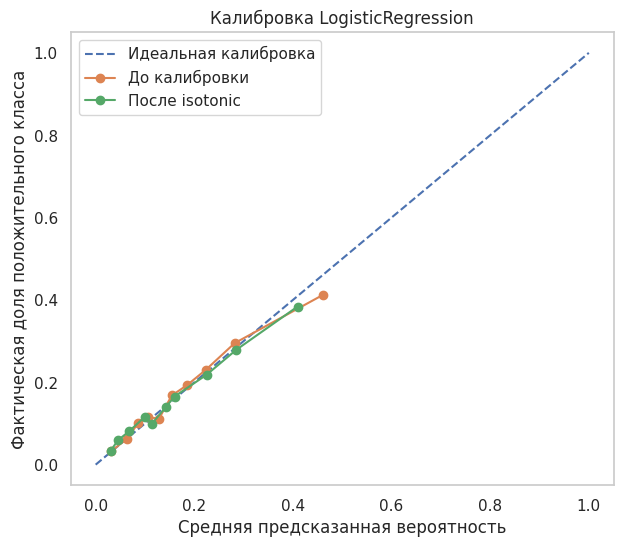

In [104]:
plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Идеальная калибровка'
)

plt.plot(
    logreg_pred_before,
    logreg_true_before,
    marker='o',
    label='До калибровки'
)

plt.plot(
    logreg_pred_after,
    logreg_true_after,
    marker='o',
    label='После isotonic'
)

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая доля положительного класса')

plt.title(
    'Калибровка LogisticRegression'
)

plt.legend()
plt.grid()

plt.show()

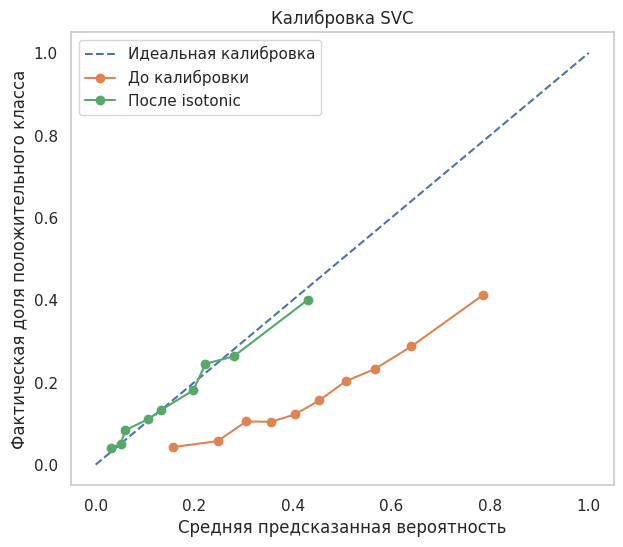

In [105]:
plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Идеальная калибровка'
)

plt.plot(
    svc_pred_before,
    svc_true_before,
    marker='o',
    label='До калибровки'
)

plt.plot(
    svc_pred_after,
    svc_true_after,
    marker='o',
    label='После isotonic'
)

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая доля положительного класса')

plt.title(
    'Калибровка SVC'
)

plt.legend()
plt.grid()

plt.show()

Калибровка вероятностей не оказала сильного влияния на логистическую регрессию. Вероятности опорных векторов стали намного ближке к идеальной калибровке.

## 10. Оценка качества калибровки

In [106]:
def calibration_errors(
    y_true,
    y_proba,
    n_bins=10
):
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    bin_ids = np.digitize(
        y_proba,
        bins[1:-1]
    )

    ece = 0.0
    mce = 0.0

    for bin_id in range(n_bins):

        mask = bin_ids == bin_id

        if not np.any(mask):
            continue

        mean_proba = y_proba[mask].mean()
        actual_rate = y_true[mask].mean()

        error = abs(
            mean_proba - actual_rate
        )

        weight = mask.mean()

        ece += weight * error
        mce = max(mce, error)

    return ece, mce

In [107]:
logreg_ece_before, logreg_mce_before = calibration_errors(
    y_test,
    logreg_before_proba
)

logreg_ece_after, logreg_mce_after = calibration_errors(
    y_test,
    logreg_after_proba
)

svc_ece_before, svc_mce_before = calibration_errors(
    y_test,
    svc_before_proba
)

svc_ece_after, svc_mce_after = calibration_errors(
    y_test,
    svc_after_proba
)

In [108]:
calibration_results = pd.DataFrame({
    'model': [
        'LogisticRegression до',
        'LogisticRegression после',
        'SVC до',
        'SVC после'
    ],

    'Brier': [
        brier_score_loss(
            y_test,
            logreg_before_proba
        ),

        brier_score_loss(
            y_test,
            logreg_after_proba
        ),

        brier_score_loss(
            y_test,
            svc_before_proba
        ),

        brier_score_loss(
            y_test,
            svc_after_proba
        )
    ],

    'ECE': [
        logreg_ece_before,
        logreg_ece_after,
        svc_ece_before,
        svc_ece_after
    ],

    'MCE': [
        logreg_mce_before,
        logreg_mce_after,
        svc_mce_before,
        svc_mce_after
    ]
})

display(calibration_results)

,model,Brier,ECE,MCE
0,LogisticRegression до,0.130174,0.011116,0.163516
1,LogisticRegression после,0.130205,0.009587,0.252914
2,SVC до,0.208951,0.270111,0.394800
3,SVC после,0.130545,0.009397,0.137681


После калибровки у LogsisticRegression оценка `Brier` практически не изменилась, `ECE` немного уменьшилась, но `MCE` выросла. Метрики же SVC значительно улучшились после калибровки. 

## 11. Финальный отчёт и выводы

In [109]:
final_logreg_ece, final_logreg_mce = calibration_errors(
    y_test,
    logreg_proba
)

final_svc_ece, final_svc_mce = calibration_errors(
    y_test,
    svc_proba
)

In [110]:
dummy_final = DummyClassifier(
    strategy='prior'
)

X_dummy_train = np.zeros(
    (len(y_train), 1)
)

X_dummy_test = np.zeros(
    (len(y_test), 1)
)

dummy_final.fit(
    X_dummy_train,
    y_train
)

dummy_test_proba = (
    dummy_final
    .predict_proba(X_dummy_test)[:, 1]
)

In [111]:
def make_report_row(
    model_name,
    y_true,
    y_score,
    y_proba,
    training_note
):
    ece, mce = calibration_errors(
        y_true,
        y_proba
    )

    return {
        'model': model_name,

        'PR-AUC': average_precision_score(
            y_true,
            y_score
        ),

        'LogLoss': log_loss(
            y_true,
            y_proba
        ),

        'Brier': brier_score_loss(
            y_true,
            y_proba
        ),

        'ECE': ece,
        'MCE': mce,

        'training': training_note
    }

In [112]:
final_report = pd.DataFrame([
    make_report_row(
        model_name='DummyClassifier',
        y_true=y_test,
        y_score=dummy_test_proba,
        y_proba=dummy_test_proba,
        training_note='Baseline'
    ),

    make_report_row(
        model_name='LogisticRegression',
        y_true=y_test,
        y_score=logreg_proba,
        y_proba=logreg_proba,
        training_note='Tuned, весь X_train'
    ),

    make_report_row(
        model_name='SVC + sigmoid',
        y_true=y_test,
        y_score=svc_scores,
        y_proba=svc_proba,
        training_note='Tuned, весь X_train'
    ),

    make_report_row(
        model_name='LogisticRegression + isotonic',
        y_true=y_test,
        y_score=logreg_after_proba,
        y_proba=logreg_after_proba,
        training_note='X_fit + отдельная calibration'
    ),

    make_report_row(
        model_name='SVC + isotonic',
        y_true=y_test,
        y_score=svc_after_proba,
        y_proba=svc_after_proba,
        training_note='X_fit + отдельная calibration'
    )
])

display(
    final_report.sort_values(
        'PR-AUC',
        ascending=False
    )
)

,model,PR-AUC,LogLoss,Brier,ECE,MCE,training
1,LogisticRegression,0.348556,0.416405,0.129872,0.011973,0.146062,"Tuned, весь X_train"
2,SVC + sigmoid,0.347301,0.610287,0.210254,0.272138,0.413250,"Tuned, весь X_train"
3,LogisticRegression + isotonic,0.330185,0.421135,0.130205,0.009587,0.252914,X_fit + отдельная calibration
4,SVC + isotonic,0.330168,0.422248,0.130545,0.009397,0.137681,X_fit + отдельная calibration
0,DummyClassifier,0.172100,0.459200,0.142482,0.000050,0.000050,Baseline


In [113]:
top5_features = (
    logreg_importance[
        [
            'feature',
            'coefficient',
            'abs_coefficient'
        ]
    ]
    .head(5)
    .reset_index(drop=True)
)

display(top5_features)

,feature,coefficient,abs_coefficient
0,device_model,4.059325,4.059325
1,app_id,3.079089,3.079089
2,site_id,3.027880,3.027880
3,C14,2.710971,2.710971
4,C18_1,-1.173662,1.173662


В ходе проекта была разработана модель прогнозирования вероятности клика пользователя по рекламному объявлению. В качестве базового решения использовался `DummyClassifier`, `PR-AUC` которого составил около 0.172, что соответствует приблизительной доле положительного класса. Обученные модели существенно превзошли данный baseline.

Наилучшее качество ранжирования показала настроенная `LogisticRegression`. После подбора гиперпараметров её PR-AUC на кросс-валидации составил около 0.374, а на тестовой выборке — около 0.349. Таким образом, качество существенно выше baseline, хотя на независимой выборке наблюдается снижение PR-AUC примерно на 0.025 относительно кросс-валидации. Это свидетельствует о некотором снижении обобщающей способности, однако резкого переобучения не наблюдается.

Наибольшие по модулю коэффициенты `LogisticRegression` получили признаки `device_model`, `app_id`, `site_id`, `C14` и одна из категорий `C18`. Следовтельно, в рамках построенной модели существенную роль играют характеристики устройства, приложения, площадки и контекста рекламного аукциона. Из-за анонимизации данных содержательная интерпретация ряда признаков ограничена.

Исходные вероятности `LogisticRegression` оказались достаточно хорошо откалиброванными: Brier Score составил около 0.130, а ECE - окло 0.011. Дополнительная isotonic-калибровка практически не улучшила Brier Score и одновременно ухудшила PR-AUC и MCE, поэтому применять её к `LogisticRegression` в финальном решении нецелесообразно.

Для `SVC` исходная калибровка была значительно хуже: Brier Score составлял около 0.209, а ECE — около 0.270. Isotonic-калибровка позволила снизить Brier Score примерно до 0.131, ECE до 0.009 и MCE до 0.138. Таким образом, калибровка особенно эффективна для `SVC`. Однако после isotonic-калибровки PR-AUC SVC снизился, поэтому с учётом того, что PR-AUC является основной метрикой проекта, LogisticRegression остаётся предпочтительной финальной моделью.

Полученное решение можно рассматривать как готовый ML-прототип, однако перед полноценным роазвертыванием желательно провести дополнительную временную валидацию, оценить устойчивость модели на более длительном периоде, организовать мониторинг качества вероятностных прогнозов.

В дальнейшем качество модели можно повысить за счёт расширения обучающей выборки и использования более длительного периода наблюдений, поскольку текущий датасет охватывает ограниченный временной диапазон. Для приближения оценки к реальному сценарию полезно дополнительно провести временную валидацию, при которой модель обучается на более ранних данных и проверяется на более поздних. Также возможно проведение расширенного feature engineering, который провести в данный момент на зашифрованных данных сложно. Стоит сравнить LogisticRegression и SVC с моделями, лучше работающими со сложными нелинейными взаимодействиями признаков.

## 12. Сохранение модели для продакшена

In [114]:
production_model = Pipeline([
    (
        'preprocessor',
        clone(final_preprocessor)
    ),

    (
        'model',
        LogisticRegression(
            C=0.1,
            class_weight=None,
            penalty='l2',
            solver='liblinear',
            max_iter=2000,
            random_state=RANDOM_SEED
        )
    )
])

In [115]:
production_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ml_feature_9']),
                                                 ('cat_oh',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['C18']),
  

In [116]:
production_proba = (
    production_model
    .predict_proba(X_test)[:, 1]
)

print(
    'PR-AUC:',
    average_precision_score(
        y_test,
        production_proba
    )
)

print(
    'LogLoss:',
    log_loss(
        y_test,
        production_proba
    )
)

print(
    'Brier:',
    brier_score_loss(
        y_test,
        production_proba
    )
)

PR-AUC: 0.3485560849934285
LogLoss: 0.4164049094363548
Brier: 0.12987170181463048


In [117]:
calibrated_preprocessor = (
    calib_preprocessing
    .named_steps['preprocessor']
)

In [118]:
X_test_pp_direct = (
    calibrated_preprocessor
    .transform(X_test)
)

np.testing.assert_allclose(
    X_test_pp_direct,
    X_test_pp
)

print('Предобработка без feature_engineering совпадает.')

Предобработка без feature_engineering совпадает.


In [119]:
calibrated_model = calibrated_svc

In [120]:
feature_info = {
    'final_features': final_features,
    'numeric_features': num_final,
    'onehot_features': cat_oh_final,
    'target_encoded_features': cat_tr_final
}

feature_info

{'final_features': ['ml_feature_9',
  'C18',
  'site_id',
  'app_id',
  'device_model',
  'C17',
  'C19',
  'C21',
  'C14'],
 'numeric_features': ['ml_feature_9'],
 'onehot_features': ['C18'],
 'target_encoded_features': ['site_id',
  'app_id',
  'device_model',
  'C17',
  'C19',
  'C21',
  'C14']}

In [121]:
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(
    exist_ok=True
)

In [122]:
joblib.dump(
    production_model,
    ARTIFACT_DIR / 'production_model.joblib'
)

joblib.dump(
    calibrated_preprocessor,
    ARTIFACT_DIR / 'preprocessor.joblib'
)

joblib.dump(
    calibrated_model,
    ARTIFACT_DIR / 'calibrated_model.joblib'
)

with open(
    ARTIFACT_DIR / 'selected_features.json',
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        feature_info,
        file,
        ensure_ascii=False,
        indent=4
    )

print('Артефакты сохранены.')

Артефакты сохранены.


In [123]:
loaded_production_model = joblib.load(
    ARTIFACT_DIR / 'production_model.joblib'
)

loaded_preprocessor = joblib.load(
    ARTIFACT_DIR / 'preprocessor.joblib'
)

loaded_calibrated_model = joblib.load(
    ARTIFACT_DIR / 'calibrated_model.joblib'
)

with open(
    ARTIFACT_DIR / 'selected_features.json',
    'r',
    encoding='utf-8'
) as file:
    loaded_feature_info = json.load(file)

In [124]:
X_new = X_test.iloc[:100].copy()

In [125]:
proba_before_save = (
    production_model
    .predict_proba(X_new)[:, 1]
)

In [126]:
proba_after_load = (
    loaded_production_model
    .predict_proba(X_new)[:, 1]
)

In [127]:
np.testing.assert_allclose(
    proba_before_save,
    proba_after_load,
    rtol=1e-12,
    atol=1e-12
)

print(
    'Production model: предсказания совпадают.'
)

Production model: предсказания совпадают.


In [128]:
X_new_pp_loaded = (
    loaded_preprocessor
    .transform(X_new)
)

calibrated_proba_loaded = (
    loaded_calibrated_model
    .predict_proba(X_new_pp_loaded)[:, 1]
)

In [129]:
X_new_pp_original = (
    calibrated_preprocessor
    .transform(X_new)
)

calibrated_proba_original = (
    calibrated_model
    .predict_proba(X_new_pp_original)[:, 1]
)

In [130]:
np.testing.assert_allclose(
    calibrated_proba_original,
    calibrated_proba_loaded,
    rtol=1e-12,
    atol=1e-12
)

print(
    'Calibrated model: предсказания совпадают.'
)

Calibrated model: предсказания совпадают.


In [131]:
prediction_check = pd.DataFrame({
    'production_logreg': (
        loaded_production_model
        .predict_proba(X_new)[:, 1]
    ),

    'calibrated_svc': (
        loaded_calibrated_model
        .predict_proba(
            loaded_preprocessor.transform(X_new)
        )[:, 1]
    )
})

display(
    prediction_check.head(10)
)

,production_logreg,calibrated_svc
0,0.391933,0.361538
1,0.317425,0.361538
2,0.079846,0.056213
3,0.433832,0.366071
4,0.242232,0.275862
5,0.105844,0.110759
6,0.132002,0.127786
7,0.223794,0.197624
8,0.105042,0.103774
9,0.353173,0.462810


Сохранены:
- пайплайн предобработки данных preprocessor;
- финальную модели calibrated_model (калиброванная SVC) и production_model (лучшая LogisticRegression);
- информация о выбранных признаках.